# **2. EDA & VISUALISATIONS**

In this notebook, we're gonna perform the entire Exploratory Data Analysis (EDA) part. This includes checking each and every feature and plotting appropriate graphs/visualisations for the same. This will help us figure out patterns and trends in each column. We're also gonna do any modifications in columns along with feature engineering, which includes creating or modifying any column for our project

#### **2.1 Importing Libraries**

The following libraries are required for this notebook

1. Pandas
2. Numpy
3. Matplotlib
4. Seaborn

We'll also be setting a style for all our Seaborn visualisations

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

#### **2.2 Loading Dataset**

Now we're gonna import the dataset that we'll be using

In [24]:
df = pd.read_csv("../data/fraud_oracle.csv")
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


#### **2.3 Checking Target Variable**

Before everything, its important to check the target variable itself

In [25]:
df["FraudFound_P"].value_counts()

FraudFound_P
0    14497
1      923
Name: count, dtype: int64

##### **2.3.1 Plotting Pie Chart**

To check the fraud distribution, we'll plot a pie-chart to look at it nicely

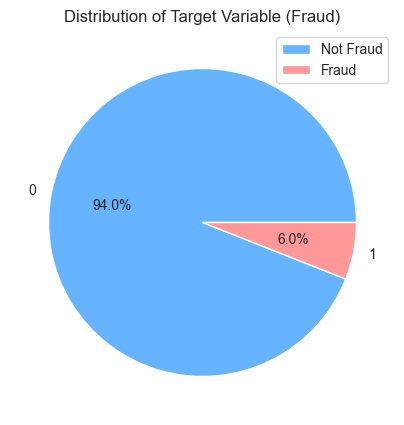

In [26]:
plt.figure(figsize=(5, 5))
df["FraudFound_P"].value_counts().plot.pie(autopct="%1.1f%%", colors=["#66b3ff", "#ff9999"])
plt.title("Distribution of Target Variable (Fraud)")
plt.legend(labels=["Not Fraud", "Fraud"], loc="upper right")
plt.show()

#### **2.4 Checking Ordinal Columns**

In this step, we're gonna study the ordinal columns. Ordinal columns are columns with categories that have a natural and meaningful order or ranking (like Small < Medium < Large). Its important for us to engineer them for our ML model. There are 2 ways to deal with this:

1. We can convert them into sequential numbers
2. We can combine them into a less no. and more meaninful categories

We'll have a look at each column and also deal with it at the same time

##### **2.4.1 Listing Ordinal Columns**

In [31]:
df["Days_Policy_Accident"].unique()

<StringArray>
['more than 30', '15 to 30', 'none', '1 to 7', '8 to 15']
Length: 5, dtype: str

In [27]:
cols_to_check = ["VehiclePrice", "Days_Policy_Accident", "Days_Policy_Claim", "PastNumberOfClaims", "AgeOfVehicle", "AgeOfPolicyHolder", "NumberOfCars", "NumberOfSuppliments", "AddressChange_Claim"]
for col in cols_to_check:
    print(f"======{col}======")
    print(df[col].value_counts())
    print("\n")

======VehiclePrice======
VehiclePrice
20000 to 29000     8079
30000 to 39000     3533
more than 69000    2164
less than 20000    1096
40000 to 59000      461
60000 to 69000       87
Name: count, dtype: int64


======Days_Policy_Accident======
Days_Policy_Accident
more than 30    15247
none               55
8 to 15            55
15 to 30           49
1 to 7             14
Name: count, dtype: int64


======Days_Policy_Claim======
Days_Policy_Claim
more than 30    15342
15 to 30           56
8 to 15            21
none                1
Name: count, dtype: int64


======PastNumberOfClaims======
PastNumberOfClaims
2 to 4         5485
none           4352
1              3573
more than 4    2010
Name: count, dtype: int64


======AgeOfVehicle======
AgeOfVehicle
7 years        5807
more than 7    3981
6 years        3448
5 years        1357
new             373
4 years         229
3 years         152
2 years          73
Name: count, dtype: int64


======AgeOfPolicyHolder======
AgeOfPolicyHolder
31

##### **2.4.2 Creating Ordinal Mapping**

We're gonna create mappings for each ordinal columns. We are creating them based on the values of each category and how close each category is to each other

In [32]:
ordinal_mapping = {
    "VehiclePrice": {
        "less than 20000": 0,
        "20000 to 29000": 1,
        "30000 to 39000": 2,
        "40000 to 59000": 3,
        "60000 to 69000": 4,
        "more than 69000": 4
    },

    "Days_Policy_Accident": {
        "none": 0,
        "1 to 7": 1,
        "8 to 15": 1,
        "15 to 30": 1,
        "more than 30": 2
    },

    "Days_Policy_Claim": {
        "none": 0,
        "8 to 15": 1,
        "15 to 30": 1,
        "more than 30": 2
    },

    "PastNumberOfClaims": {
        "none": 0,
        "1": 1,
        "2 to 4": 2,
        "more than 4": 3
    },

    "AgeOfVehicle": {
        "new": 0,
        "2 years": 1,
        "3 years": 1,
        "4 years": 2,
        "5 years": 2,
        "6 years": 3,
        "7 years": 4,
        "more than 7": 4
    },

    "AgeOfPolicyHolder": {
        "16 to 17": 0,
        "18 to 20": 0,
        "21 to 25": 0,
        "26 to 30": 1,
        "31 to 35": 1,
        "36 to 40": 1,
        "41 to 50": 2,
        "51 to 65": 3,
        "over 65": 4
    },

    "NumberOfCars": {
        "1 vehicle": 0,
        "2 vehicles": 1,
        "3 to 4": 2,
        "5 to 8": 2,
        "more than 8": 2
    },

    "NumberOfSuppliments": {
        "none": 0,
        "1 to 2": 1,
        "3 to 5": 2,
        "more than 5": 3
    },

    "AddressChange_Claim": {
        "no change": 0,
        "under 6 months": 2,
        "1 year": 2,
        "2 to 3 years": 1,
        "4 to 8 years": 1
    }
}

**2.4.1.1 Copying Original Dataset**

As we're about to make some changes in the dataset, its better to copy the original dataset in case we'll have to come back

In [50]:
df_copy = df.copy()

##### **2.4.2 Applying Ordinal Mapping**

Now we're gonna apply the mappings that we created to the columns itself. We'll apply it on the columns only without creating new columns

In [33]:
for col in ordinal_mapping.keys():
    df[col] = df[col].astype(str).str.strip().str.lower()

for col, mapping in ordinal_mapping.items():
    df[col] = df[col].map(mapping)

##### **2.4.5 Saving Ordinal Columns**

We're gonna note down these ordinal columns so we can refer to them again when applying encoding

In [16]:
ordinal_cols = cols_to_check

##### **2.4.6 Plotting Graphs for Ordinal Columns**

Now we're gonna plot count plot for all the ordinal columns. Although in the following visualisations, we're gonna see the new ordinal mapping, we have already saved the visualisations with actual values for website. To check visualisations with original values, we may run this part of the code before ordinal mapping

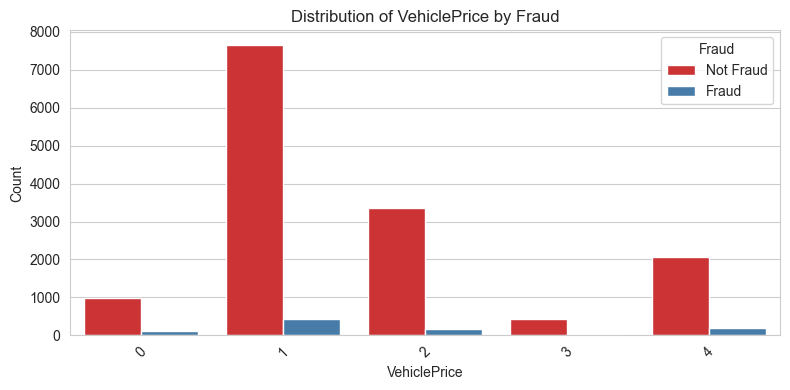

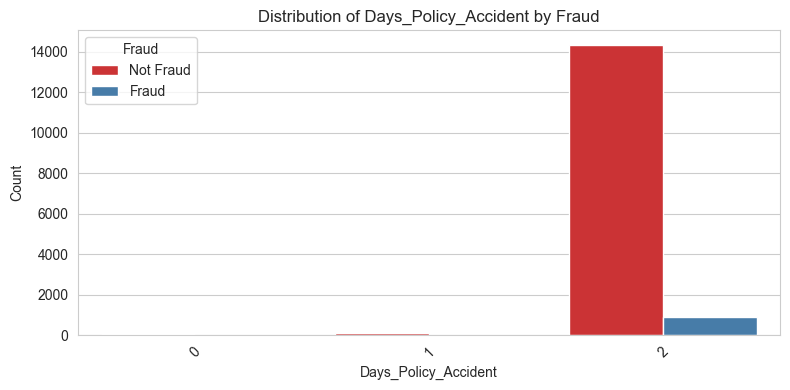

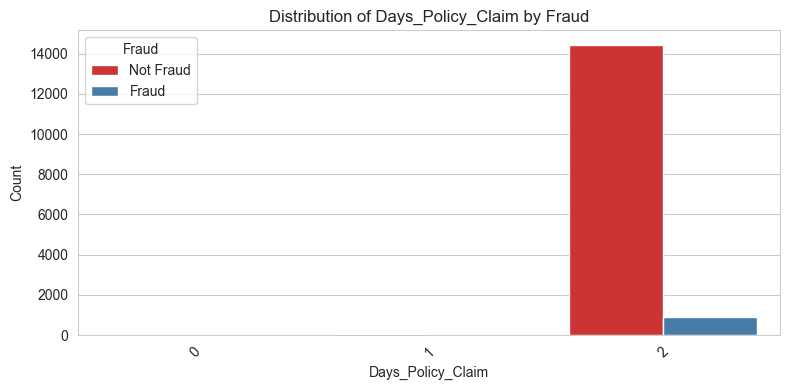

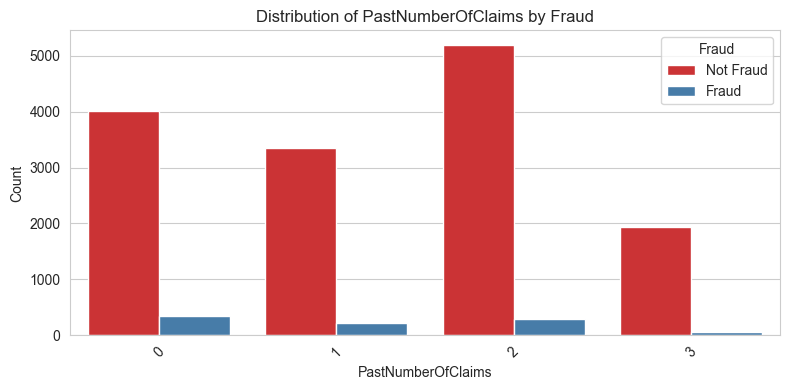

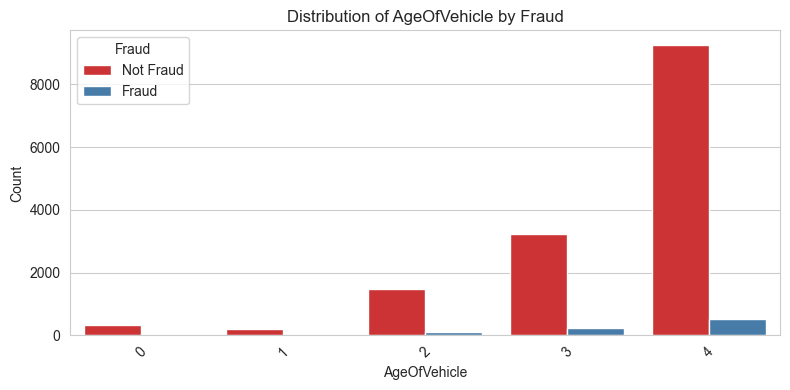

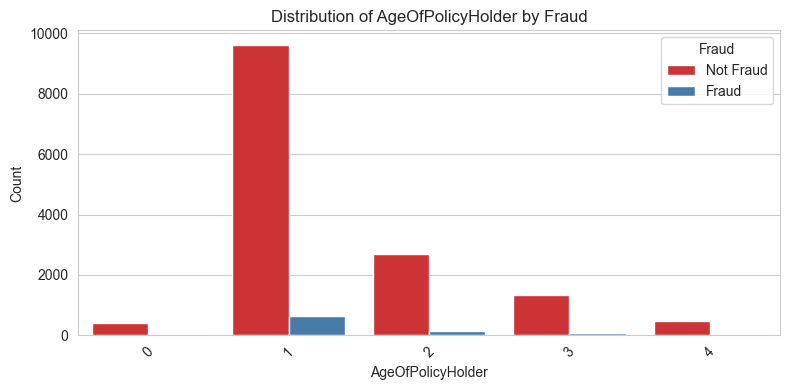

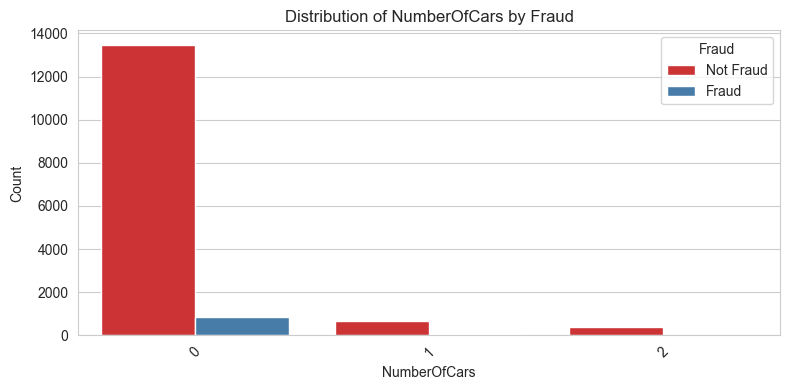

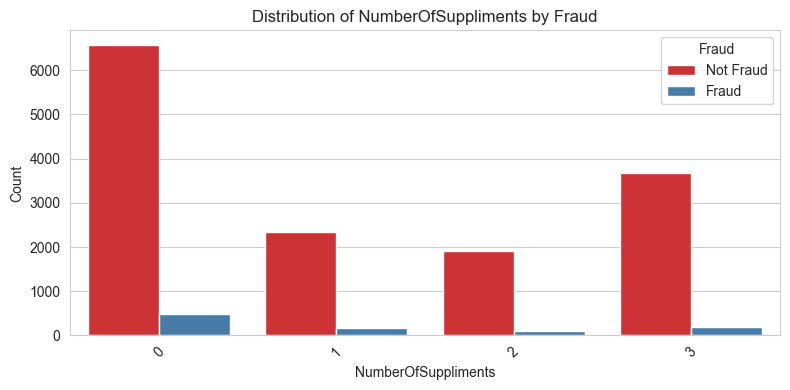

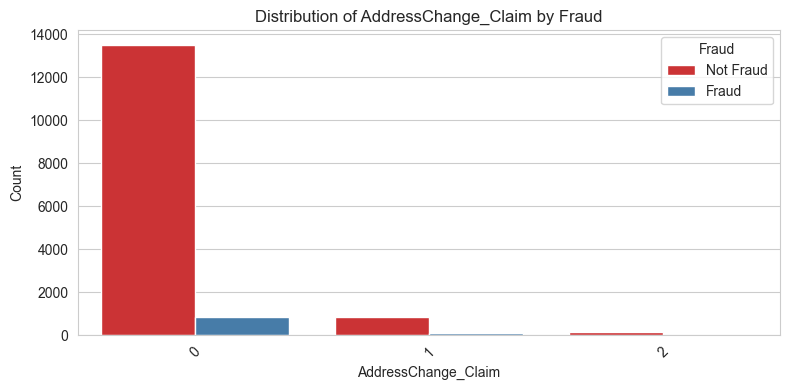

In [36]:
for col in cols_to_check:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue="FraudFound_P", data=df, palette="Set1")
    plt.title(f"Distribution of {col} by Fraud")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Fraud", labels=["Not Fraud", "Fraud"])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

#### **2.5 Time-Related Features**

In this step we're gonna have a look at time-related features specifically Month, Week and Weekday related features. We'll convert the string values into integers so that its easier for our model to work with

In [37]:
time_features = ["Month", "MonthClaimed", "DayOfWeek", "DayOfWeekClaimed", "WeekOfMonth", "WeekOfMonthClaimed"]
df[time_features].sample(5)

,Month,MonthClaimed,DayOfWeek,DayOfWeekClaimed,WeekOfMonth,WeekOfMonthClaimed
8567,Dec,Dec,Tuesday,Wednesday,2,3
9835,May,May,Tuesday,Thursday,1,1
7391,Sep,Oct,Thursday,Friday,5,5
2442,Jul,Jul,Monday,Thursday,1,1
9342,Mar,Mar,Sunday,Wednesday,2,3


As you can see, Month is written as Jan, Feb, etc. format and Weekday is written as Monday, Tuesday, etc. format. We have to change them into their respective numbers. So basically Jan will become 1, Tuesday will become 2 and so on

##### **2.5.1 Converting Month Names to Numbers**

Firstly, we're gonna convert the Month values to numbers

In [38]:
df["Month"] = df["Month"].map(
    {
        "Jan": 1,
        "Feb": 2,
        "Mar": 3,
        "Apr": 4,
        "May": 5,
        "Jun": 6,
        "Jul": 7,
        "Aug": 8,
        "Sep": 9,
        "Oct": 10,
        "Nov": 11,
        "Dec": 12,
    }
)

df["MonthClaimed"] = df["MonthClaimed"].map(
    {
        "Jan": 1,
        "Feb": 2,
        "Mar": 3,
        "Apr": 4,
        "May": 5,
        "Jun": 6,
        "Jul": 7,
        "Aug": 8,
        "Sep": 9,
        "Oct": 10,
        "Nov": 11,
        "Dec": 12,
    }
)

##### **2.5.2 Converting Day Names to Numbers**

Now we're gonna convert Weekday values into numbers

In [39]:
df["DayOfWeek"] = df["DayOfWeek"].map(
    {
        "Monday": 1,
        "Tuesday": 2,
        "Wednesday": 3,
        "Thursday": 4,
        "Friday": 5,
        "Saturday": 6,
        "Sunday": 7,
    }
)

df["DayOfWeekClaimed"] = df["DayOfWeekClaimed"].map(
    {
        "Monday": 1,
        "Tuesday": 2,
        "Wednesday": 3,
        "Thursday": 4,
        "Friday": 5,
        "Saturday": 6,
        "Sunday": 7,
    }
)

In [41]:
df[time_features].sample(5)

,Month,MonthClaimed,DayOfWeek,DayOfWeekClaimed,WeekOfMonth,WeekOfMonthClaimed
5716,8,8.0,5,1.0,3,4
646,1,1.0,1,2.0,3,4
13550,2,2.0,5,3.0,1,2
13461,10,10.0,5,2.0,3,3
1329,11,11.0,2,3.0,4,4


As we can see, all our time-related features are now in number format and not in strings

##### **2.5.3 Creating Time Delay Features**

In this step, we're gonna create time delay features. These features don't exist in the dataset so these are first bunch of feature engineering columns that we're gonna create. Basically, a good fraud indicator is how long was the wait between the month of incident and the month of claim. So we're gonna check the delay (or the time between the incident and claim). After that we'll have a look at how much important as an indicator that is

In [34]:
df["MonthDelay"] = (df["MonthClaimed"] - df["Month"]) % 12
df["DayDelay"] = (df["DayOfWeekClaimed"] - df["DayOfWeek"]) % 7
df["WeekDelay"] = (df["WeekOfMonthClaimed"] - df["WeekOfMonth"]) % 5

df["MonthDelay"] = df["MonthDelay"].astype("Int64")
df["DayDelay"] = df["DayDelay"].astype("Int64")
df["WeekDelay"] = df["WeekDelay"].astype("Int64")

In [35]:
df[["MonthDelay", "DayDelay", "WeekDelay"]].sample(5)

,MonthDelay,DayDelay,WeekDelay
9762,0,5,1
10843,2,0,3
11446,1,3,1
14476,0,6,1
10029,0,2,1


As we can see, the month, day and week delay features are engineering into the dataset

**2.5.3.1 Dropping Old Columns**

Now we can drop the old time-related columns. At this point of the project, we haven't yet tested both cases of dropping or not. So if this code is commented, that means the project gets more accuracy not dropping these columns, otherwise we'll drop it

In [42]:
# df.drop(columns=time_features, inplace=True)

##### **2.5.4 Plotting The New Time-Related Features**

In this step, we're gonna plot a mean plot to check the avg delay in Month, Weekday and Week and group it by fraud or not fraud. That way we'll be able to know how much delay is usually causing Fraud on avg

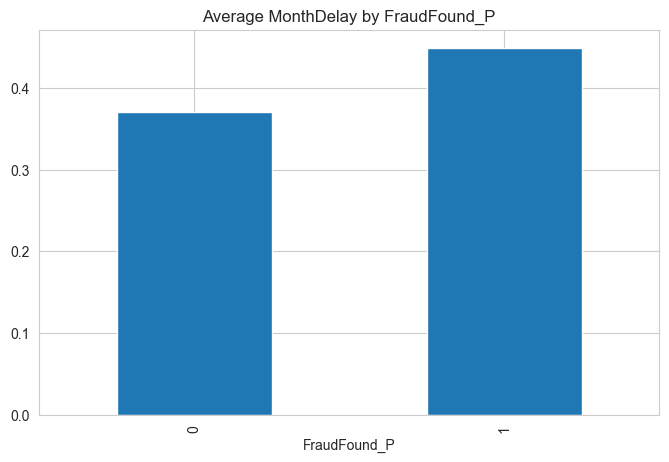

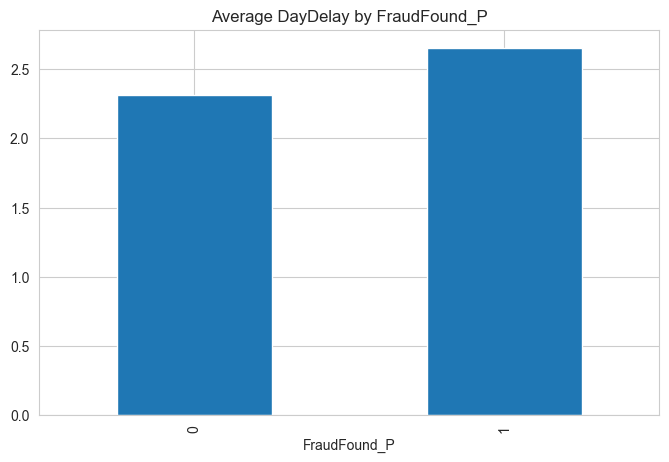

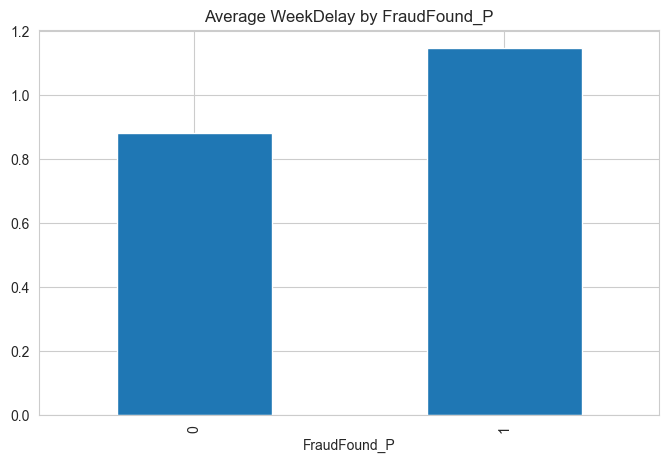

In [72]:
time_delay_cols = ["MonthDelay", "DayDelay", "WeekDelay"]

for col in time_delay_cols:
    df.groupby("FraudFound_P")[col].mean().plot(kind="bar", figsize=(8, 5))
    plt.title(f"Average {col} by FraudFound_P")
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

As we can see, the higher the delay no matter Month, Weekday or week, the higher the chances of fraud. We can conclude that this is a good indicator for our model

#### **2.6 Categorical Columns**

In this step we're gonna have a look at the remaining categorical columns. The time-related and ordinal columns that we engineered were also part of the categorical columns. So, we'll work on the other columns that were left out

In [53]:
cols_left = df.select_dtypes(include="object").columns.drop(cols_to_check).tolist()
cols_left

['Make',
 'AccidentArea',
 'Sex',
 'MaritalStatus',
 'Fault',
 'PolicyType',
 'VehicleCategory',
 'PoliceReportFiled',
 'WitnessPresent',
 'AgentType',
 'BasePolicy']

**2.6.1 Finding Value Counts of Each Column**

In [54]:
for col in cols_left:
    print(f"======{col}======")
    print(df[col].value_counts())
    print("\n")

======Make======
Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64


======AccidentArea======
AccidentArea
Urban    13822
Rural     1598
Name: count, dtype: int64


======Sex======
Sex
Male      13000
Female     2420
Name: count, dtype: int64


======MaritalStatus======
MaritalStatus
Married     10625
Single       4684
Divorced       76
Widow          35
Name: count, dtype: int64


======Fault======
Fault
Policy Holder    11230
Third Party       4190
Name: count, dtype: int64


======PolicyType======
PolicyType
Sedan - Collision       5584
Sedan - Liability       4987
Sedan - All Perils      4087
Sport - Collision        348
Utility - All Perils     340
Utility - Colli

As we can see, the Make and Policy Type columns can be dropped as they have very less entries and are redundant so they may cause problems in our ML training. We'll also combine some categories of Marital Status due to less entries

##### **2.6.1 Dropping The Columns**

In [43]:
df.drop(columns = ["Make", "PolicyType"], inplace=True)

##### **2.6.2 Engineering Marital Status Column**

To do this, we're gonna combine Divorced, Widow and Single categories into Not Married. This will eliminate the problem of less entries for the categories

In [68]:
df["MaritalStatus"] = df["MaritalStatus"].map(
    {
        "Single": "Not Married",
        "Divorced": "Not Married",
        "Widow": "Not Married",
        "Married": "Married"
    }
)

##### **2.6.3 Engineering Witness Present Column**

In this, we're gonna check the Witness Present feature as we found out that it has less entries as well, but the feature might be of use

In [58]:
df["WitnessPresent"].value_counts()

WitnessPresent
No     15333
Yes       87
Name: count, dtype: int64

What we can do here is combine the Witness Present feature with the Police Report Filed feature as both are quite related to each other

In [59]:
df["PoliceReportFiled"].value_counts()

PoliceReportFiled
No     14992
Yes      428
Name: count, dtype: int64

Now we'll combine them as a feature where the value will be 0 if either witness was present or police report was filed and 1 if neither witness was present nor police report was filed

In [60]:
df["NoWitnessNoPoliceReport"] = np.where((df["WitnessPresent"] == "No") & (df["PoliceReportFiled"] == "No"), "Yes", "No")

In [62]:
df.groupby("NoWitnessNoPoliceReport")["FraudFound_P"].value_counts()

NoWitnessNoPoliceReport  FraudFound_P
No                       0                 457
                         1                  18
Yes                      0               14040
                         1                 905
Name: count, dtype: int64

As you can see, around 900 cases exist where when there was no witness and no police report filed were fraud

**2.6.3.1 Dropping Witness Present Column**

We can safely drop the Witness Present column now as we have found its use somewhere

In [63]:
df.drop("WitnessPresent", axis=1, inplace=True)

##### **2.6.4 Plotting These Remaining Columns**

In this step, we're gonna plot a count plot for all the remaining columns w.r.t. fraud

<Figure size 800x500 with 0 Axes>

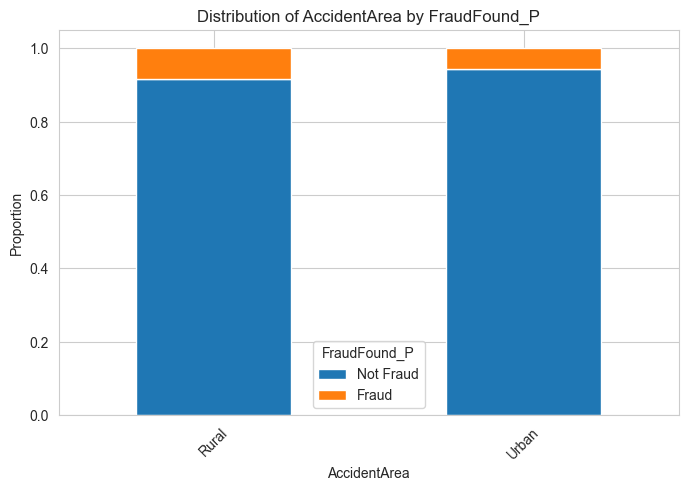

<Figure size 800x500 with 0 Axes>

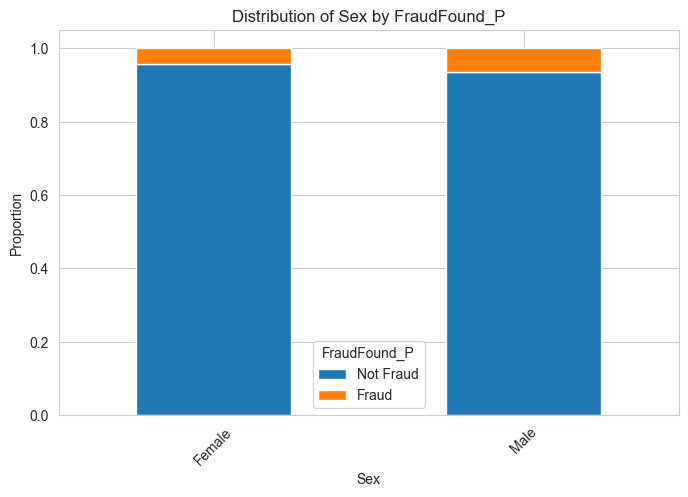

<Figure size 800x500 with 0 Axes>

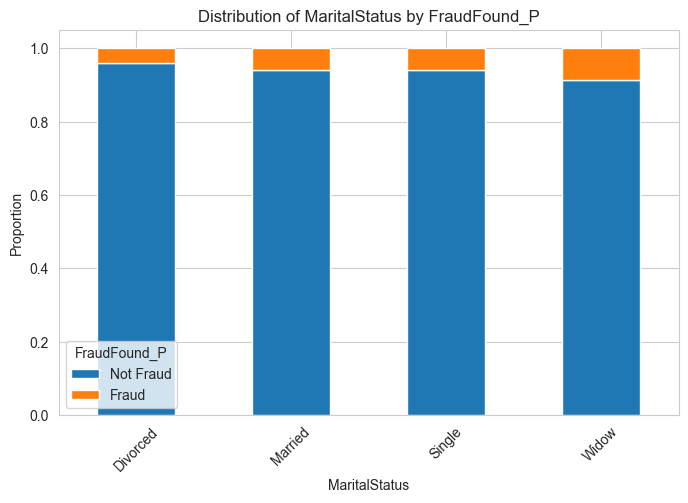

<Figure size 800x500 with 0 Axes>

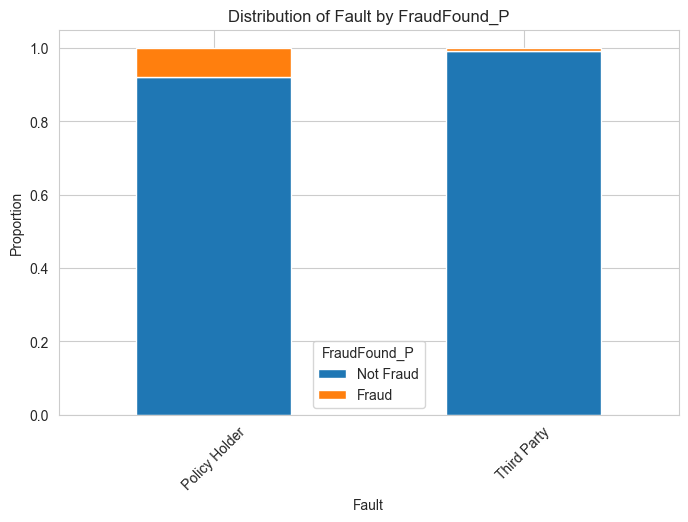

<Figure size 800x500 with 0 Axes>

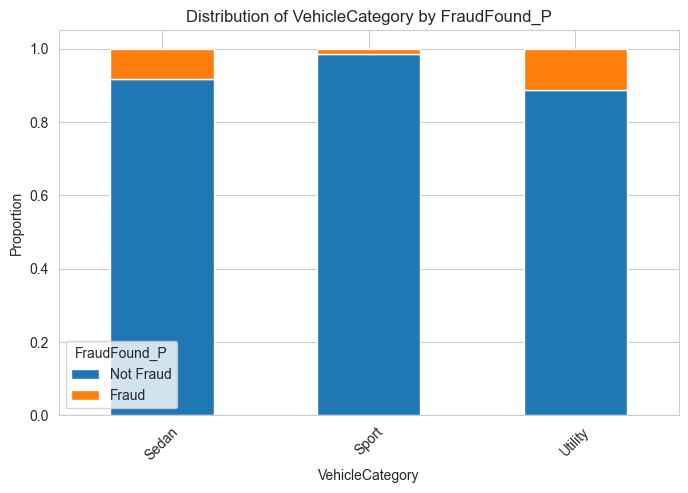

<Figure size 800x500 with 0 Axes>

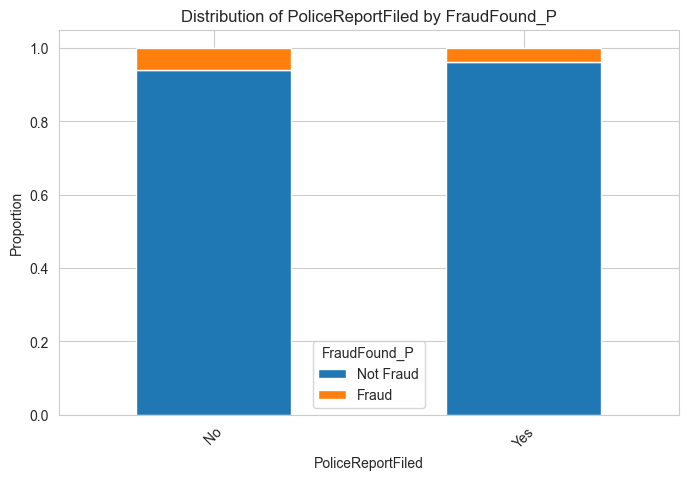

<Figure size 800x500 with 0 Axes>

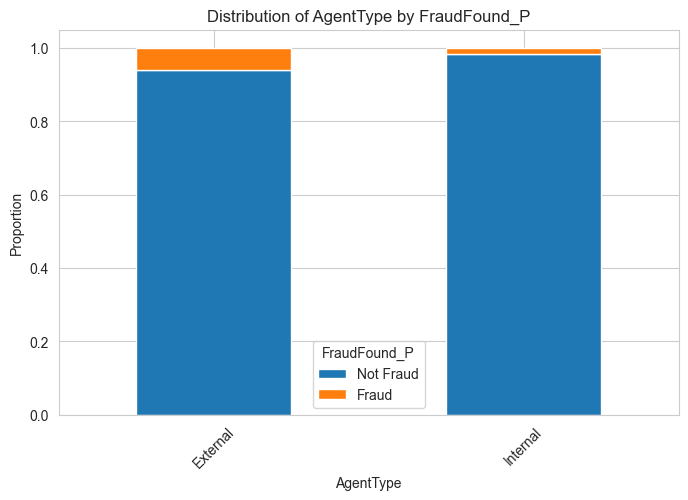

<Figure size 800x500 with 0 Axes>

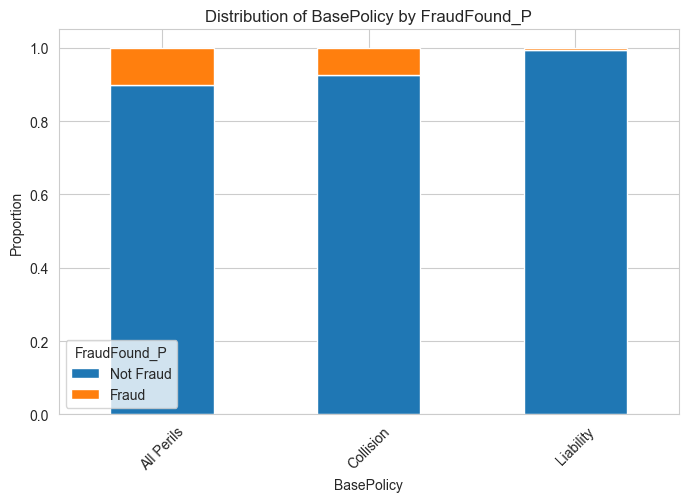

In [44]:
for col in ['AccidentArea','Sex','MaritalStatus','Fault','VehicleCategory','PoliceReportFiled','AgentType','BasePolicy']:
    plt.figure(figsize=(8, 5))
    df.groupby(col)["FraudFound_P"].value_counts(normalize=True).unstack().plot(kind="bar", stacked=True, figsize=(8, 5))
    plt.title(f"Distribution of {col} by FraudFound_P")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.legend(title="FraudFound_P", labels=["Not Fraud", "Fraud"])
    plt.xticks(rotation=45)
    plt.show()
    print("\n")
    print("="*90)
    print("\n")

### **2.7 Numerical Columns**

In this step, we're gonna work with the last columns left which are the numerical columns

In [74]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("FraudFound_P").tolist()
num_cols

['Age',
 'PolicyNumber',
 'RepNumber',
 'Deductible',
 'DriverRating',
 'Year',
 'MonthDelay',
 'DayDelay',
 'WeekDelay']

We're gonna drop Policy Number and Rep Number columns as they just represent IDs or serial no. along with Year which doesn't seem to be a good indicator

##### **2.7.1 Dropping The Columns**

In [76]:
df.drop(columns=["PolicyNumber", "RepNumber", "Year"], inplace=True)

##### **2.7.2 Checking Remaining Columns**

In this step, we're gonna check the remaining columns. We won't be using the value counts to check here rather we'll find the minimum, maximum and mean value of each feature as they are best suited for numerical features

In [77]:
for col in ["Age", "Deductible", "DriverRating"]:
    print(f"======{col}======")
    print("Max", df[col].max())
    print("Min", df[col].min())
    print("Mean", df[col].mean())
    print("\n")

======Age======
Max 80
Min 0
Mean 39.855706874189366


======Deductible======
Max 700
Min 300
Mean 407.70428015564204


======DriverRating======
Max 4
Min 1
Mean 2.4878080415045396




As we can see, there are some cases where age is 0. This is definitely a fault which we'll fix. The rest of them seem fine

##### **2.7.3 Fixing Faulty Ages**

In [46]:
df["Age"][df["Age"] < 16].value_counts()

Age
0    320
Name: count, dtype: int64

As we can see, there are 320 cases where age is 0

**2.7.3.1 Checking Fault or Delibrate Mistake**

We have to check if these are delibrate faults which may have been filled by potential fraudsters to fake their age

In [47]:
df["FraudFound_P"][df["Age"] == 0].value_counts()

FraudFound_P
0    289
1     31
Name: count, dtype: int64

As we can see, only 31 fraud cases show that this might just be a fault in the dataset. So, we'll just remove these columns

**2.7.3.2 Removing Entries Where Age = 0**

In [48]:
df.drop(df[df["Age"] < 16].index, inplace=True)

In [49]:
df["Age"].min()

np.int64(16)

### **2.8 Exporting The Dataset**

In this notebook we have made many changes. So, its important for us to save or export this new dataset in our directory. We're gonna keep this new and the original dataset both in our directory

##### **2.8.1 Checking Dataset Before Export**

Before exporting, we'll have a quick look at basic info as a final check

In [126]:
df.columns

Index(['AccidentArea', 'Sex', 'MaritalStatus', 'Age', 'Fault',
       'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'Deductible',
       'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim',
       'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder',
       'PoliceReportFiled', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'BasePolicy', 'MonthDelay',
       'DayDelay', 'WeekDelay', 'NoWitnessNoPoliceReport',
       'LessAgeExpensiveVehicle'],
      dtype='str')

In [127]:
df.info()

<class 'pandas.DataFrame'>
Index: 15100 entries, 0 to 15419
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   AccidentArea             15100 non-null  str  
 1   Sex                      15100 non-null  str  
 2   MaritalStatus            15100 non-null  str  
 3   Age                      15100 non-null  int64
 4   Fault                    15100 non-null  str  
 5   VehicleCategory          15100 non-null  str  
 6   VehiclePrice             15100 non-null  str  
 7   FraudFound_P             15100 non-null  int64
 8   Deductible               15100 non-null  int64
 9   DriverRating             15100 non-null  int64
 10  Days_Policy_Accident     15100 non-null  str  
 11  Days_Policy_Claim        15100 non-null  str  
 12  PastNumberOfClaims       15100 non-null  str  
 13  AgeOfVehicle             15100 non-null  str  
 14  AgeOfPolicyHolder        15100 non-null  str  
 15  PoliceReportFiled 

#### **2.8.2 Exporting**

In [52]:
df.to_csv("../data/new_data.csv", index=False)

#### **2.9 Notebook Summary**

**Dataset Engineering**

- We dropped columns that were not required
- We converted Month and Weekday columns into numeric
- We mapped many ordinal columns
- We engineering some new features like:
    1. Month delay
    2. Weekday delay
    3. Week delay
    4. No Witness Present & No Police Report Filed

**Data Visualisations**

- We plotted many graphs for almost each column
- We investigated many hidden patterns in columns

**Insights:**

- There were not many flags to create by combining features
- We have to check whether to drop time-related columns or not